# EDA

Name: Anna Reimers

Date: 02/01/2026




<a id="introduction"></a>
## Introduction

### Project Goal, Business, and Analytical Problems

Home Credit faces the challenge of minimizing home loan default risk while limiting the exclusion of worthy applicants due to insufficient credit history. Telco and transactional data supplement information on customer credit history to help Home Credit estimate risk and decide on loan terms and offers.
To approach this classification task, loan-default probability predictions will be generated using a supervised learning approach with historical loan-default outcome data. This includes information regarding customer applications, credit bureau history, cash and credit balance, previous application history, and installments. Feature engineering and merging of tables will be necessary to encapsulate all relevant predictors.Home Credit can use predicted probabilities by setting a risk threshold which will be used to convert the default-probability to the binary label: default or no-default.

### EDA Goal and Data Questions

The goal of this exploratory data analysis is to develop and further the initial understanding of the Home Credit Default Risk dataset prior to model development. This analysis focuses on examining the format and quality of the data, looking into the distribution of the target variable, and identifying potential data setbacks such as missing values or outliers. The takeaways from the EDA will inform preprocessing, feature selection, and modeling decisions in later stages of the project.





<a id="description"></a>
## Description of the Data

### What does the data look like, how is it structured?



In [14]:
# Import the data files
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/home_credit
!unzip "/content/drive/MyDrive/Collab/home-credit-default-risk.zip" -d /content/home_credit




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
home-credit-default-risk.zip
Archive:  /content/drive/MyDrive/Collab/home-credit-default-risk.zip
replace /content/home_credit/HomeCredit_columns_description.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: application_test.csv	 HomeCredit_columns_description.csv
application_train.csv	 installments_payments.csv
bureau_balance.csv	 POS_CASH_balance.csv
bureau.csv		 previous_application.csv
credit_card_balance.csv  sample_submission.csv


In [17]:
import pandas as pd

BASE_PATH = "/content/home_credit"

application_train = pd.read_csv(f"{BASE_PATH}/application_train.csv")
application_test  = pd.read_csv(f"{BASE_PATH}/application_test.csv")


((307511, 122), (48744, 121))

In [18]:
# Find the size of applicaton train and test datasets
application_train.shape, application_test.shape


((307511, 122), (48744, 121))

### Data Shape:
The application train dataset is contains 307,511 observations and 122 columns. The application test dataset contains 48,744 rows and the same 121 features excluding the target variable.

### Granularity:
Each row in application_train.csv represents a single loan application submitted to Home Credit. A row contains current demographic, financial, employment, credit related information about the applicant, and characteristics of the loan.



In [21]:
# Explore the target variable
application_train['TARGET'].value_counts()


,count
TARGET,
0,282686
1,24825


### Target variable:
The target variable in the application train/test datasets is the "TARGET" column. It is a binary representation of whether or not the customer defaulted on their loan, with a 1 representing default.

### Supplementary Datasets:
- **bureau.csv** :  Contains information on the applicant’s previous loans from other financial institutions that were reported to the credit bureau. Each row represents a single previous credit associated with a current applicant.
- **bureau_balance.csv** : Contains monthly status information for each credit reported in bureau.csv. Each row represents one month of history for a single bureau credit.
- **previous_application.csv** :
Contains information on previous loan applications made by the client to Home Credit. Each row represents one prior application.
- **POS_CASH_balance.csv** : Contains monthly balance snapshots of point-of-sale and cash loans previously held by the applicant with Home Credit.
- **credit_card_balance.csv** : Contains monthly balance information for credit cards previously held by the applicant with Home Credit.
- **installments_payments.csv** : Contains payment history for previous Home Credit loans, such as on-time and missed installment payments.

Together, this group of datasets provides both applicant information and behavioral data. This data will eventually be aggregated and joined to add depth to the indicator variables that are used for modeling loan default risk.

## Discussion of Missing Data

### The scope of missing data and the proposed solution.



In [26]:
# Compute the percentage of missing data in each column from application_train
missing_data = application_train.isna().mean().sort_values(ascending=False)
missing_data.head(25)

,0
COMMONAREA_AVG,0.698723
COMMONAREA_MODE,0.698723
COMMONAREA_MEDI,0.698723
NONLIVINGAPARTMENTS_MEDI,0.694330
NONLIVINGAPARTMENTS_MODE,0.694330
NONLIVINGAPARTMENTS_AVG,0.694330
FONDKAPREMONT_MODE,0.683862
LIVINGAPARTMENTS_AVG,0.683550
LIVINGAPARTMENTS_MEDI,0.683550
LIVINGAPARTMENTS_MODE,0.683550


In [25]:
missing_data.describe()

,0
count,122.000000
mean,0.243959
std,0.284465
min,0.000000
25%,0.000000
50%,0.003320
75%,0.508180
max,0.698723


### Scope of Missing Data
Looking into the application_train dataset more closely, it is clear that there are some columns with high amounts of perceived "missing" values. However, upon closer examination this high proportion of missing values in several housing related variables is likely due to the nature of existence of a variable as opposed to true missingness. This is because many features are only applicable to certain types of residences, for example "COMMONAREA_AVG" refers to whether or not there is a common area, which is only applicable to apartment buildings. For many applicants, these characteristics do not exist, resulting in the appearance of structurally missing data. However, there are also many variabls such as "LANDAREA_AVG" which contains almost 60% missing values and is due to true lack of data existence. These situations will need to be dealt with differnetly than structural missingness. Structural missingess can be combatted through data manipulation and cleaning, since entries merely need to be transformed into informative data. Dealing with true missing values will be more of a challenge and decently subjective based on the situation.

### Proposed Solutions for Missing Data

1. **Categorize Missing Data**: The first step to counteracting the missing data is understanding whether it is structural missingness (housing related features not applicable to all applicants) or true missingness where there is no value recorded.
2. **Strategy**: For features with very high proportions of structural missingness (over 40%), these variables will either be excluded from modeling or transformed by introducing explicit missing indicators. This choice will depend on the specific variable. To solve the issue of features with moderate missingness, numerical variables can be imputed using median values, while categorical variables can be imputed using the mode category or an explicit “Missing” label rather than a 'NA'.

The final approach will aim to balance as much data retention as possible while limiting the risk that comes with of significant imputations.


## Exploratory Visuals & Summary Tables

### What does the data look like and how does it behave?

:

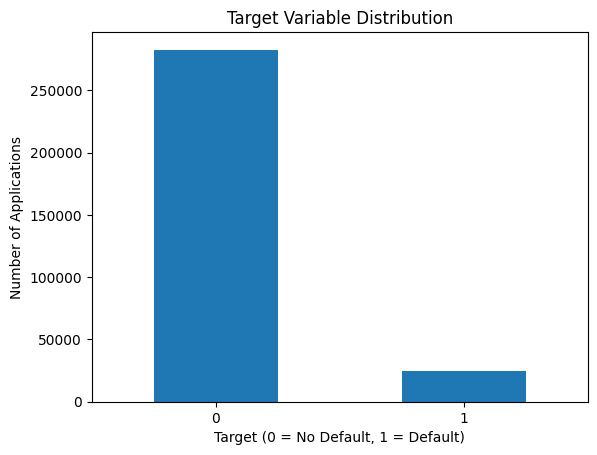

In [28]:
# Target variable exploration

target_counts = application_train['TARGET'].value_counts()
target_counts
import matplotlib.pyplot as plt

# Bar plot of target distribution
target_counts.plot(kind='bar')

plt.title('Target Variable Distribution')
plt.xlabel('Target (0 = No Default, 1 = Default)')
plt.ylabel('Number of Applications')
plt.xticks(rotation=0)
plt.show()

In [29]:
# Find the majority class accuracy
target_counts = application_train['TARGET'].value_counts()
baseline_accuracy = target_counts.max() / target_counts.sum()

target_counts, baseline_accuracy

(TARGET
 0    282686
 1     24825
 Name: count, dtype: int64,
 np.float64(0.9192711805431351))

The bar chart shows a highly imbalanced target variable distribution. The majority of loan applications do not result in default (target = 0), while a much smaller proportion of applicants default on their loans (target = 1). This imbalance shows that the dataset is skewed toward non-default cases and that accuracy alone would be a misleading evaluation metric for predictive models.

A majority class classifier, which would always predict the majority class (target = 0) would have an accuracy of 91.92%. While this accuracy appears high, this type of model would fail to successfully classify any default cases.In this case, the business problem is that these defaults are of great interest due to the negative effects that they have on Home Credit. Therefore, this  highlights the need for further evaluation metrics which may include recall, precision, and AUC and a more complex model.

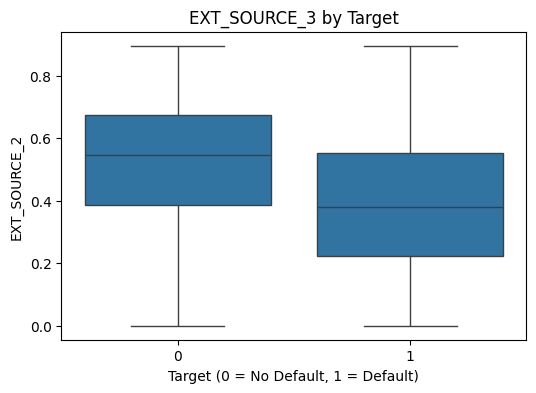

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(
    x='TARGET',
    y='EXT_SOURCE_3',
    data=application_train
)
plt.title('EXT_SOURCE_3 by Target')
plt.xlabel('Target (0 = No Default, 1 = Default)')
plt.ylabel('EXT_SOURCE_2')
plt.show()

**Strongest Predictors**: Intuitively, certain predictors seem to be more likely to effect the target variable. For example, above is plotted the distributions of "EXT_SOURCE_3" for default and no default. "EXT_SOURCE_3" represents a normalized score provided externally and used by Home Credit to assess applicant creditworthiness. While the scoring methods are not explicity provided, higher values generally indicate lower credit risk and vice versa. The box plot shows a decent difference in mean, quartiles, and range based on this variable alone.

In [31]:
# Find the numeric columns
numeric_cols = application_train.select_dtypes(include=['int64', 'float64'])

# Find each of those numeric columns correlation with the target
target_corr = numeric_cols.corr()['TARGET'].sort_values(ascending=False)

# Remove target
top_positive = target_corr[1:11]
top_negative = target_corr[-10:]

top_positive, top_negative

(DAYS_BIRTH                     0.078239
 REGION_RATING_CLIENT_W_CITY    0.060893
 REGION_RATING_CLIENT           0.058899
 DAYS_LAST_PHONE_CHANGE         0.055218
 DAYS_ID_PUBLISH                0.051457
 REG_CITY_NOT_WORK_CITY         0.050994
 FLAG_EMP_PHONE                 0.045982
 REG_CITY_NOT_LIVE_CITY         0.044395
 FLAG_DOCUMENT_3                0.044346
 DAYS_REGISTRATION              0.041975
 Name: TARGET, dtype: float64,
 ELEVATORS_AVG                -0.034199
 REGION_POPULATION_RELATIVE   -0.037227
 AMT_GOODS_PRICE              -0.039645
 FLOORSMAX_MODE               -0.043226
 FLOORSMAX_MEDI               -0.043768
 FLOORSMAX_AVG                -0.044003
 DAYS_EMPLOYED                -0.044932
 EXT_SOURCE_1                 -0.155317
 EXT_SOURCE_2                 -0.160472
 EXT_SOURCE_3                 -0.178919
 Name: TARGET, dtype: float64)

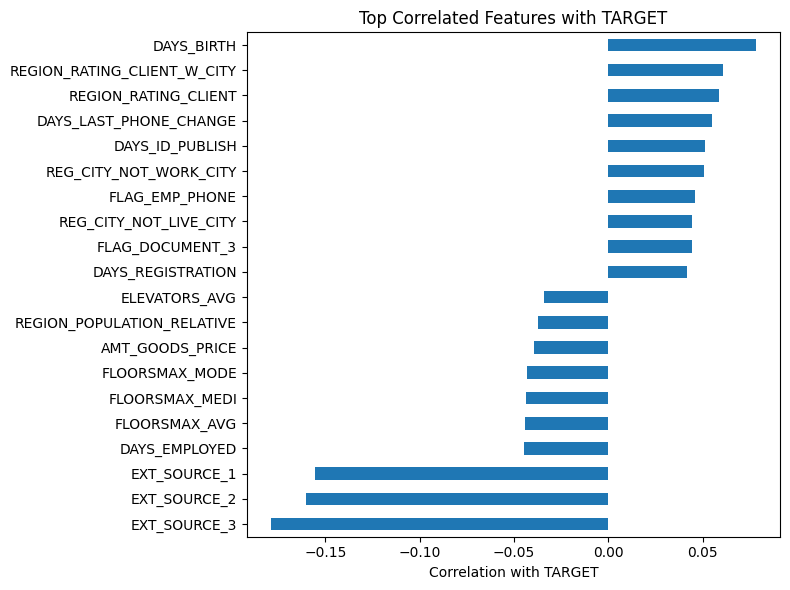

In [32]:
top_corr = pd.concat([top_positive, top_negative])

# Plot
plt.figure(figsize=(8,6))
top_corr.sort_values().plot(kind='barh')
plt.title('Top Correlated Features with TARGET')
plt.xlabel('Correlation with TARGET')
plt.tight_layout()
plt.show()

**Top Numeric Predictors**: Just by running some simple code, the numeric columns with the highest absolute correltaions(highest correlations positive and negative) to the target variable were plotted above. From the results, it stands out that "EXT_SOURCE_1", "EXT_SOURCE_2", and "EXT_SOURCE_3" have the largest negative correlations with the target variable. On the other hand, "DAYS_BIRTH", "REGION_RATING_CLIENT_W_CITY", and "REGION_RATING_CLIENT" have the highest positive correlations with the target. After data preprocessing, when the modeling process is started these variables will be the first ones to be included as indicator variables as they are inform the model the most.  

## Results



### Overall Findings & Modeling Implications

Exploratory data analysis revealed a large, feature rich dataset with a highly imbalanced target variable, where the majority of applicants do not default. A simple majority-class classifier would achieve high accuracy while underscoring the need for more informative evaluation metrics in future modeling. The key business objective focuses on minimizing home loan default risk, which will require a more complex classifier to be solved.

Several numeric predictors, particularly the externally sourced credit scores (EXT_SOURCE_1, EXT_SOURCE_2, and EXT_SOURCE_3), showed the strongest negative correlations with default risk. Additionally, there are substantial amounts of missing data throughout the dataset, mostly concerning housing-related features. Upon further examination, much of this missingness can be attributed to structural issues rather than true missingness. This suggests that there is a need for careful preprocessing, data imputation, feature selection, and appropriate modeling strategies will be critical for effective default risk prediction.


## Exporting Notebook as HTML

This workflow will probably require some debugging.

1. Click File >>> Download >>> Download .ipynb.
2. Move the downloaded file to your project folder.
3. Open a terminal in your project directory and run `python3 -m nbconvert --to html case_template.ipynb`
4. The compiled (HTML) version of your document should appear in that folder.




